In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

import statsmodels.api as sm

In [ ]:
df = pd.read_csv(r"C:\Users\alkal\Downloads\Telegram Desktop\titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
X = pd.DataFrame()

X["sex"] = df["Sex"]
X["age"] = df["Age"]
X["pclass"] = df["Pclass"]
X["sibsp"] = df["SibSp"]
X["parch"] = df["Parch"]
X["Embarked"] = df["Embarked"]

y = df["Survived"]

In [ ]:
X["age"] = X["age"].fillna(X["age"].median())

X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

In [ ]:
X["sex"] = pd.get_dummies(X["sex"])["female"]

In [ ]:
X = X.join(pd.get_dummies(X["pclass"], prefix="pclass"))

X.drop(["pclass","pclass_1"],axis=1,inplace=True)

In [ ]:
X = X.join(pd.get_dummies(X["Embarked"],prefix="Embarked"))

X.drop(["Embarked","Embarked_C"],axis=1,inplace=True)

In [ ]:
scaler = StandardScaler()

X["age"] = scaler.fit_transform(X[["age"]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
print("Training Accuracy :",model.score(X_train,y_train))
print("Testing Accuracy :",model.score(X_test,y_test))

Training Accuracy : 0.8061797752808989
Testing Accuracy : 0.8044692737430168


In [ ]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test,y_pred))

[[90 15]
 [20 54]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



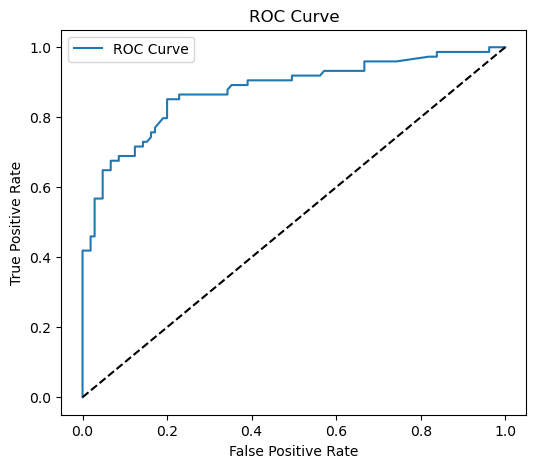

ROC AUC : 0.8767696267696268


In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label="ROC Curve")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC AUC :",roc_auc_score(y_test,y_prob))

In [ ]:
print(X_train.select_dtypes(include=['object']))

Empty DataFrame
Columns: []
Index: [331, 733, 382, 704, 813, 118, 536, 361, 29, 55, 865, 595, 239, 721, 81, 259, 486, 716, 800, 781, 542, 326, 534, 535, 483, 762, 533, 713, 390, 495, 482, 377, 365, 412, 468, 409, 7, 580, 155, 880, 425, 101, 199, 424, 298, 884, 247, 478, 305, 316, 2, 405, 742, 260, 367, 158, 554, 829, 677, 380, 626, 302, 432, 522, 404, 843, 355, 464, 753, 212, 449, 79, 148, 428, 60, 660, 804, 588, 765, 265, 133, 708, 544, 346, 821, 633, 456, 500, 430, 445, 650, 172, 450, 314, 332, 801, 90, 834, 181, 581, ...]

[712 rows x 0 columns]


In [ ]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [ ]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

In [ ]:
logit = sm.Logit(y_train, X_train_sm)

result = logit.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.447792
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      703
Method:                           MLE   Df Model:                            8
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:                  0.3239
Time:                        22:11:22   Log-Likelihood:                -318.83
converged:                       True   LL-Null:                       -471.54
Covariance Type:            nonrobust   LLR p-value:                 2.882e-61
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2716      0.272      0.998      0.318      -0.262       0.805
sex            2.7221      0.

In [ ]:
# Predict probability
y_pred = result.predict(X_test_sm)

# Convert to DataFrame
predicted_df = pd.DataFrame(y_pred)

# Convert probability to class (0 or 1)
predicted_df['Predicted_Class'] = np.where(predicted_df[0] >= 0.5, 1, 0)

predicted_df.head()

,0,Predicted_Class
709,0.109010,0
439,0.258322,0
840,0.116144,0
720,0.911510,1
39,0.758787,1


In [ ]:
cols = ['Model','R-Squared Value','ROC Score',
        'Precision Score','Recall Score',
        'Accuracy Score','Kappa Score']

models_report = pd.DataFrame(columns=cols)

from sklearn import metrics

tmp1 = pd.Series({
    'Model': "Logistic Regression Base Model",
    'R-Squared Value': result.prsquared,
    'ROC Score': metrics.roc_auc_score(y_test, predicted_df['Predicted_Class']),
    'Precision Score': metrics.precision_score(y_test, predicted_df['Predicted_Class']),
    'Recall Score': metrics.recall_score(y_test, predicted_df['Predicted_Class']),
    'Accuracy Score': metrics.accuracy_score(y_test, predicted_df['Predicted_Class']),
    'Kappa Score': metrics.cohen_kappa_score(y_test, predicted_df['Predicted_Class'])
})

model1_report = pd.concat([models_report, tmp1.to_frame().T], ignore_index=True)

print(model1_report)

                            Model R-Squared Value ROC Score Precision Score  \
0  Logistic Regression Base Model        0.323859  0.798198        0.794118   

  Recall Score Accuracy Score Kappa Score  
0      0.72973       0.810056    0.603621  
